# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan adalah Credit Risk Dataset. Dataset ini berisi informasi profil debitur untuk memprediksi status pinjaman (loan_status), apakah akan gagal bayar (default) atau tidak. Fitur-fiturnya meliputi usia, pendapatan, lama kerja, tujuan pinjaman, suku bunga, dan lain-lain.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [9]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib
import kagglehub

# Konfigurasi visualisasi
%matplotlib inline
sns.set(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [10]:
#Type your code here

# Download latest version
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

df = pd.read_csv(path+"/credit_risk_dataset.csv")

# Menampilkan 5 data teratas
print("Dataset Head:")
display(df.head())

# Menampilkan informasi dasar dataset
print("\nDataset Info:")
df.info()

Dataset Head:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [11]:
#Type your code here
# 1. Mengecek Nilai Kosong
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [12]:
# 2. Statistik Deskriptif
display(df.describe())

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


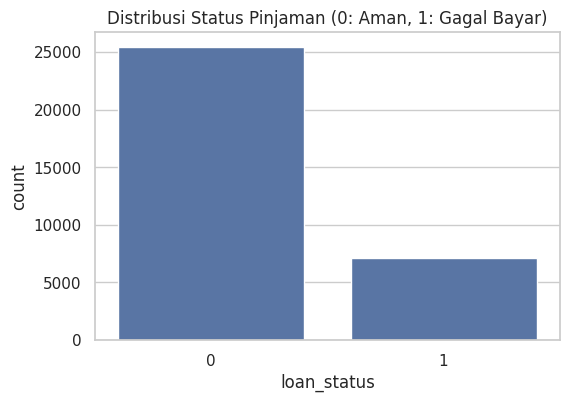

In [13]:
# 3. Visualisasi Distribusi Target (loan_status)
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df)
plt.title('Distribusi Status Pinjaman (0: Aman, 1: Gagal Bayar)')
plt.show()

/tmp/ipykernel_55/3560766088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=df[col], palette="Set2")
/tmp/ipykernel_55/3560766088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=df[col], palette="Set2")
/tmp/ipykernel_55/3560766088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=df[col], palette="Set2")
/tmp/ipykernel_55/3560766088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `l

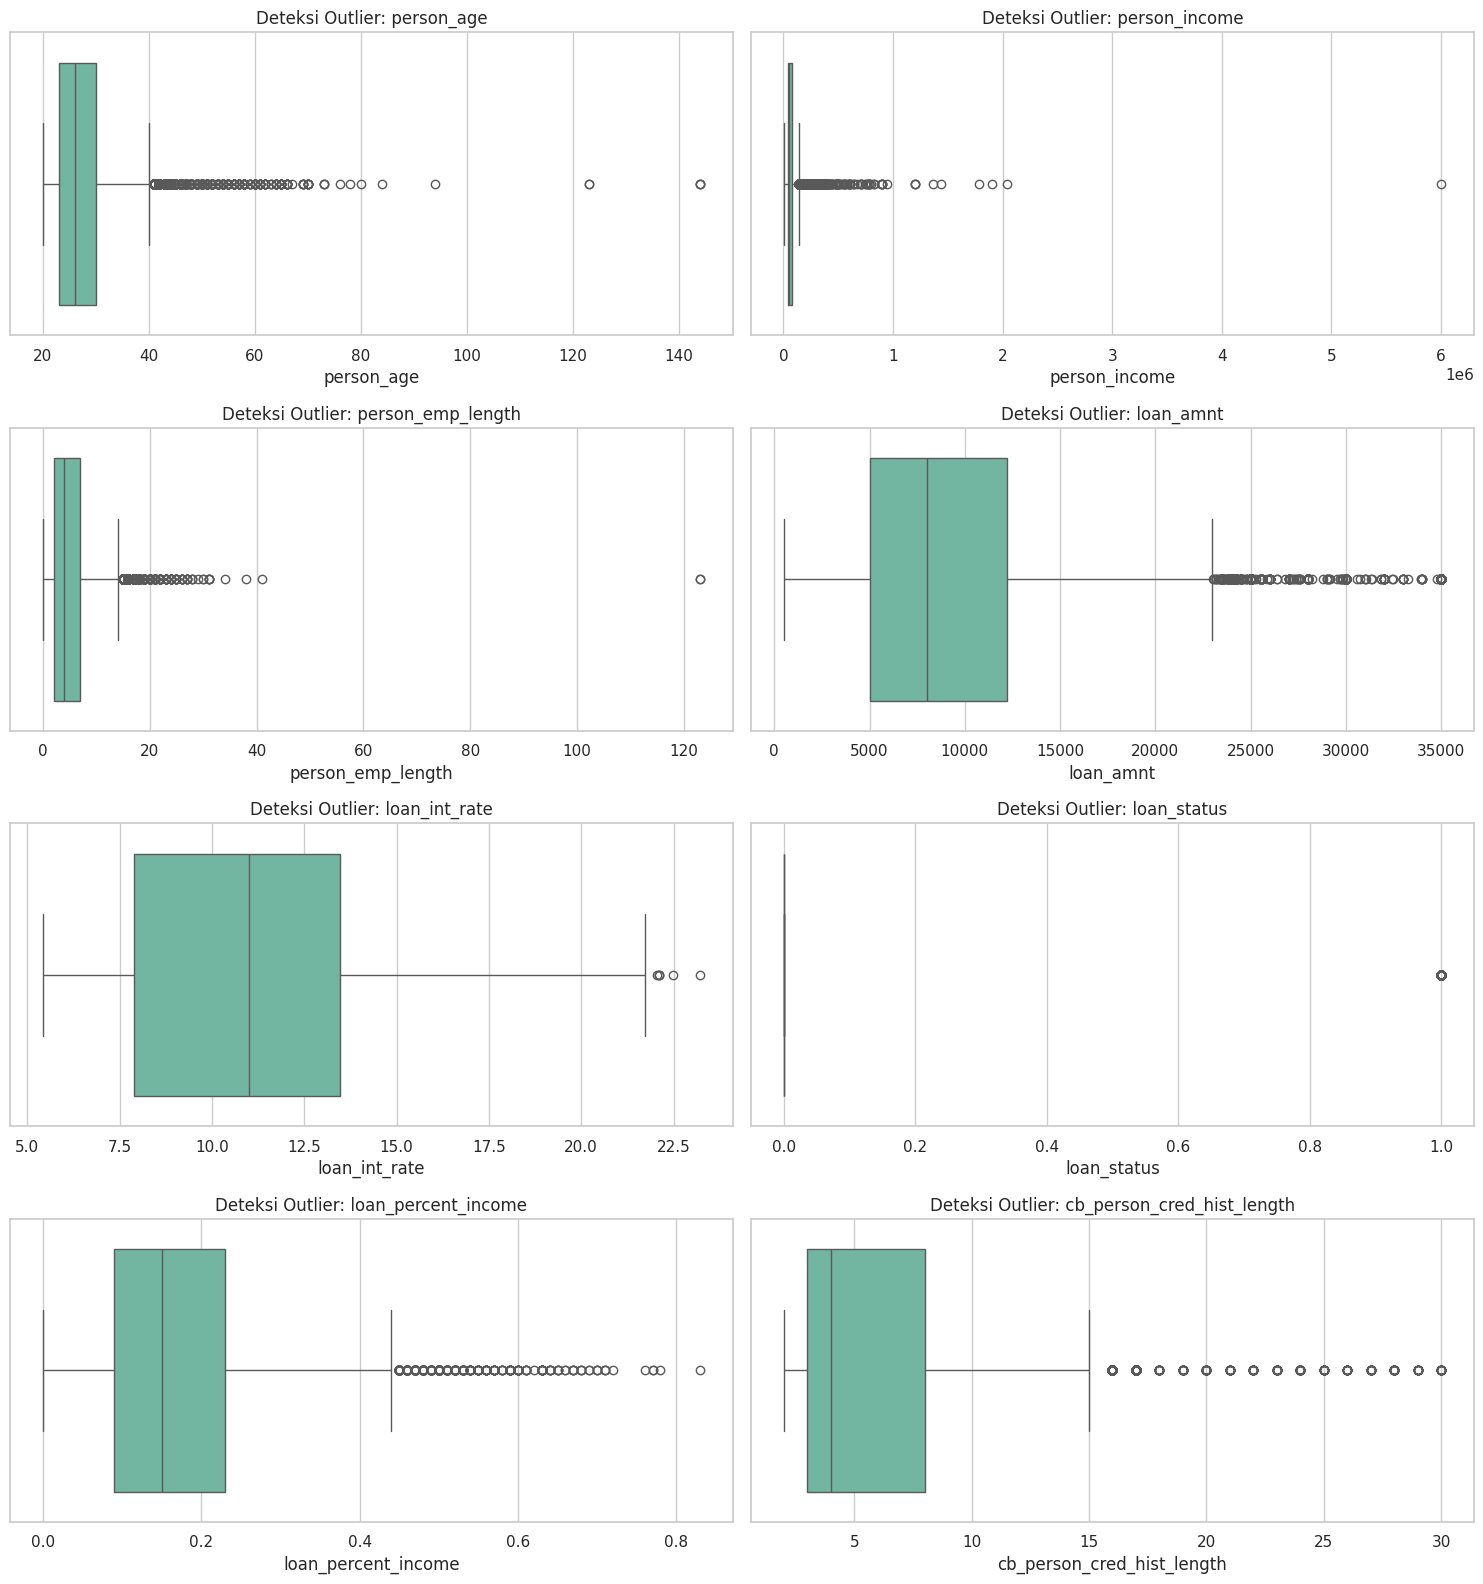

In [14]:
# 4.1. Identifikasi variabel numerik
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 4.2. Deteksi Outlier untuk SEMUA variabel numerik
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(ax=axes[i], x=df[col], palette="Set2")
    axes[i].set_title(f'Deteksi Outlier: {col}', fontsize=12)

# Hapus axes yang kosong jika jumlah kolom ganjil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

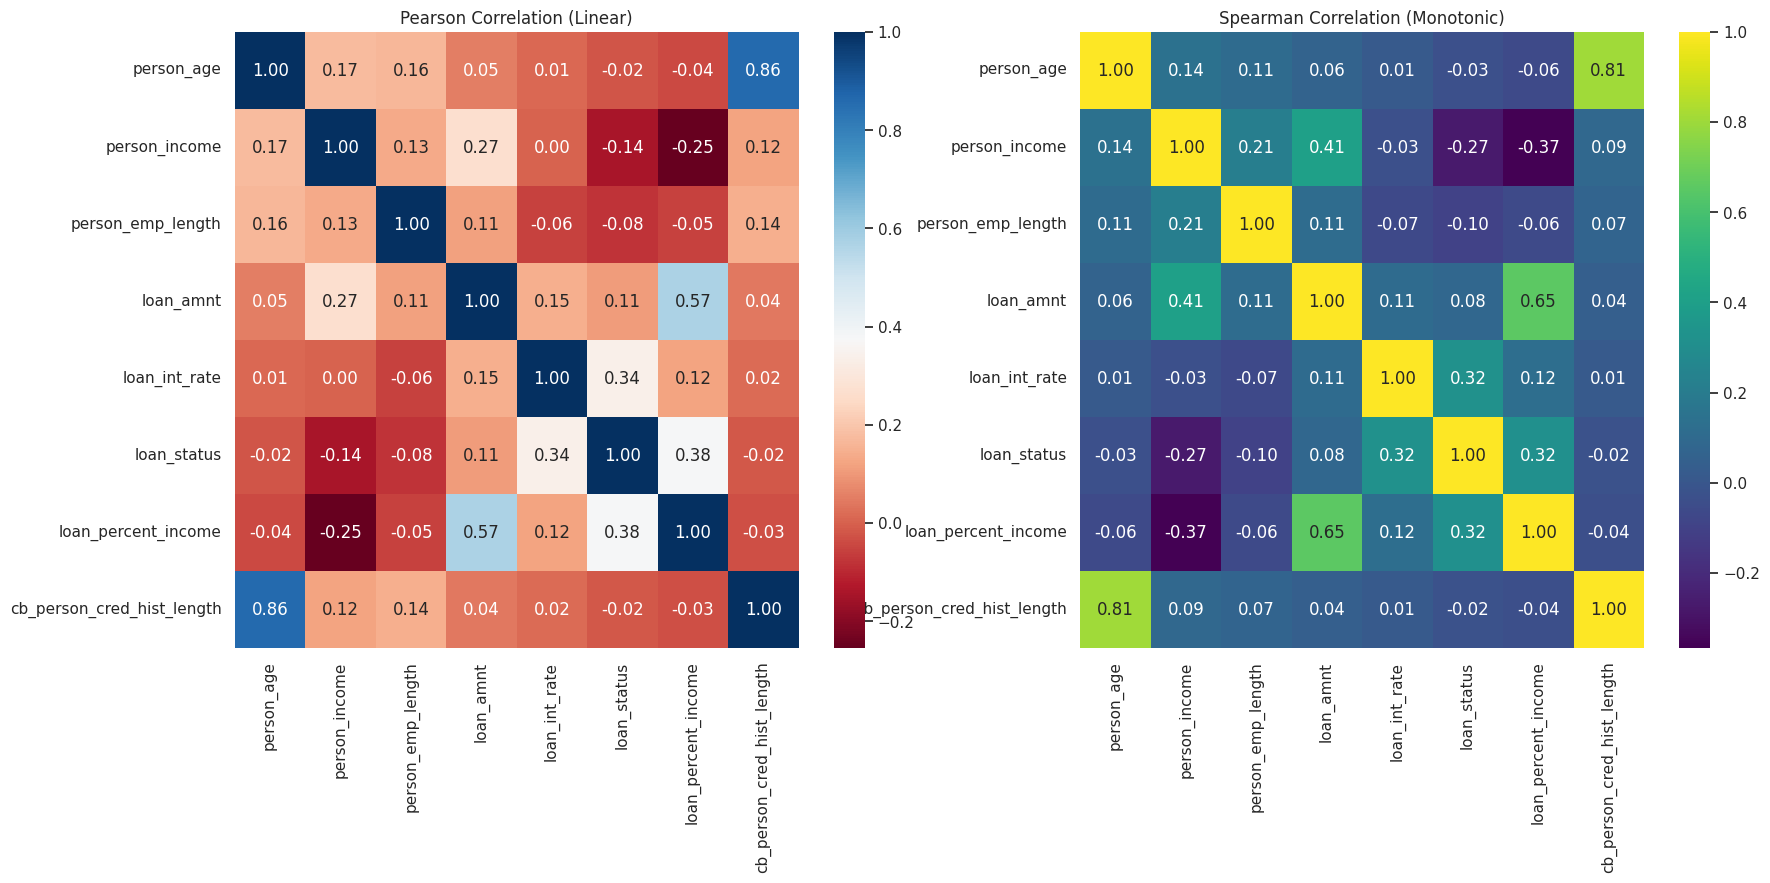

In [15]:
# 5. Korelasi antar fitur numerik
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Pearson - Linear Correlation
sns.heatmap(df[num_cols].corr(method='pearson'), annot=True, cmap='RdBu', fmt='.2f', ax=axes[0])
axes[0].set_title('Pearson Correlation (Linear)', fontsize=12)

# Spearman - Rank Correlation
sns.heatmap(df[num_cols].corr(method='spearman'), annot=True, cmap='viridis', fmt='.2f', ax=axes[1])
axes[1].set_title('Spearman Correlation (Monotonic)', fontsize=12)

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [19]:
# --- 1. Handling Missing Values & Data Duplikat ---
# Kita ingin data yang "riil", maka kita hapus yang kosong dan duplikat di awal
df_clean = df.copy()
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()

# --- 2. Deteksi dan Penanganan Outlier (Logical Filtering) ---
# Filter dilakukan SEBELUM scaling agar outlier tidak merusak perhitungan statistik (mean/std)
df_clean = df_clean[df_clean['person_age'] <= 90]
df_clean = df_clean[df_clean['person_emp_length'] <= 50]
df_clean = df_clean[df_clean['person_income'] <= 1000000]

# --- 3. Feature Encoding ---
# A. Ordinal Encoding untuk loan_grade (Sesuai diskusi: Grade A=1, B=2, dst.)
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_clean['loan_grade'] = df_clean['loan_grade'].map(grade_mapping)

# B. Binary Encoding untuk Default History
df_clean['cb_person_default_on_file'] = df_clean['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

# C. One-Hot Encoding untuk fitur Nominal (tanpa urutan)
nominal_cols = ['loan_intent', 'person_home_ownership']
df_clean = pd.get_dummies(df_clean, columns=nominal_cols)

# --- 4. Pemisahan Fitur dan Target ---
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

# --- 5. Feature Scaling (Standardization) ---
# Gunakan RobustScaler karena masih ada sisa pencilan di kolom income/amount
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_final = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Preprocessing Selesai")
print(f"Data Awal: {len(df)} | Data Akhir: {len(df_clean)} | Fitur: {X_final.shape[1]}")
display(X_final.head())

Preprocessing Selesai
Data Awal: 32581 | Data Akhir: 28489 | Fitur: 19


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
0,-0.714286,-1.142646,0.2,0.0,-0.933333,0.026882,-0.357143,0.0,-0.4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0
1,-0.142857,-1.142646,-0.6,0.5,-0.333333,0.336918,3.000000,0.0,-0.2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-1.0
2,-0.428571,0.236920,0.0,0.5,3.600000,0.759857,2.714286,0.0,-0.4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.285714,-0.037019,0.8,0.5,3.600000,0.587814,2.857143,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.714286,-1.135242,-0.4,-0.5,-0.733333,-0.689964,0.714286,0.0,-0.4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.0
